# Chapter 15 — Capstone: a mini research project

!!! info "Before you start"
    **Prerequisites:** Ch 11 (HI & Galactic Rotation), Ch 12 (VLA Imaging), Ch 13 (Pulsars), Ch 14 (Multi-wavelength) · **Maths Lab:** none · **~90 min** · **Advanced**

> *"The unit of radio brightness, the jansky, bears his name, and so does this
> course."* — and this is where you earn yours.

This is the final chapter, and it is different from every one before it. There is
no new equation to derive and no new algorithm to implement. Instead you take the
toolkit you have built across fourteen chapters and **do a small piece of real
research** from end to end:

1. **Pose a question** that a radio dataset can actually answer.
2. **Access data** — from an open archive via `astroquery`/`jansky.data`, with a
   synthetic fallback so you are never blocked.
3. **Reduce & analyse** it with the methods from Parts I–IV.
4. **Make a figure** that communicates the result.
5. **Interpret** it against the published literature.

That five-step arc *is* the scientific method as practised in radio astronomy.
A professional VLA or MeerKAT project is the same loop with bigger data and more
calibration in step 3.

### What you already know (the whole course in one breath)

| Part | Chapters | Skill you now have |
|------|----------|--------------------|
| **I — Foundations** | 1–3 | brightness temperature, the jansky, noise, the **radiometer equation** $\Delta T = T_\mathrm{sys}/\sqrt{B\tau}$ |
| **II — Instrumentation** | 4–6 | antenna beams & resolution $\theta\sim\lambda/D$, receivers, the 21 cm line |
| **III — Interferometry** | 7–9 | the *uv*-plane, the dirty beam, **Högbom CLEAN** |
| **IV — Real research** | 10–14 | open archives (SIMBAD/VizieR/HEASARC/`pyvo`), HI rotation curves, CASA imaging, pulsar de-dispersion & folding |

This chapter is a **scaffold**: the prose, the citations, the library calls, and
one fully worked skeleton are here, but the heart of the analysis is left to you
as clearly-marked `# TODO` cells. Pick a track, fill them in, and you will have
produced an original mini-result.

### Learning goals

- Frame a tractable research question and identify the dataset that answers it.
- Run the full **access → reduce → figure → interpret** loop independently.
- Write up a result the way researchers do: a short, citable **research note**.
- Know where to go next — workshops, software, and real proposal calls.

## Choose your project: three tracks

Pick **one**. Each reuses chapters you have already done; each ends in a single
figure plus a paragraph of interpretation. The estimates assume you reuse the
helper code from the referenced chapters.

### Track A — An HI rotation curve (reuse Ch 11)
**Question:** *How fast does gas orbit in a galaxy (or the Milky Way), and is
there evidence for dark matter?*

- **Data:** an HI 21 cm spectral-line cube — the HI4PI all-sky survey
  (`jansky.data.fetch("hi4pi-sample")`) for the Milky Way, or a published cube
  for an external galaxy (e.g. THINGS).
- **Steps:** load the cube → build the velocity field (moment-1 map) →
  extract a rotation curve $v_\mathrm{rot}(R)$ → overlay a flat curve and a
  Keplerian $v\propto R^{-1/2}$ decline → read off the missing mass.
- **Reuse:** the cube loader, `velocity_field`, and the rotation-curve code from
  **Chapter 11**; `jansky.units` for any brightness-temperature steps.
- **The punchline you are reproducing:** Rubin & Ford (1970) — flat curves imply
  unseen mass.

### Track B — Image & characterise a radio source (reuse Ch 8–9, 12)
**Question:** *What does this radio source look like, and what is its flux
density / structure?*

- **Data:** real visibilities imaged in CASA (Ch 12), or — fully offline — a
  **synthetic field** you build and image with `jansky.interferometry`.
- **Steps:** define a sky model (or load a measurement set) → compute *uv*
  coverage → form the dirty image and dirty beam → run **Högbom CLEAN** →
  measure the source (peak, integrated flux, size) and compare to a catalogue
  value (NVSS/VLASS via VizieR from Ch 10).
- **Reuse:** `interferometry.uv_coverage`, `dirty_beam`, `dirty_image`,
  `hogbom_clean`; `units.flux_to_brightness_temperature`.
- **The punchline:** aperture synthesis + deconvolution recover a sky you can
  *measure*, the way Högbom (1974) made practical.

### Track C — Fold / de-disperse a pulsar (reuse Ch 13)  ⭐ *worked below*
**Question:** *Can I recover a pulsar's pulse profile from noisy, dispersed
single-dish data, and measure its period and dispersion measure?*

- **Data:** a known pulsar's parameters from the **ATNF Pulsar Catalogue**
  (`psrqpy`/VizieR) plus a time–frequency "filterbank"; offline we **simulate**
  a faint dispersed, periodic signal buried in noise.
- **Steps:** de-disperse across frequency to correct the $\propto\nu^{-2}$
  dispersion delay → fold the time series at the period → measure the
  signal-to-noise of the recovered profile → estimate the period and DM.
- **Reuse:** the radiometer intuition from **Chapter 3** (signal emerging from
  noise) and the de-dispersion/folding logic from **Chapter 13**.
- **The punchline you are reproducing:** Hewish, Bell, et al. (1968) — a periodic
  radio source pulled out of the noise.

The rest of this notebook **works Track C end-to-end as a skeleton**, with the
analysis left to you. If you pick A or B instead, the same scaffolding pattern
(real call → `try/except` → synthetic fallback → `# TODO`) applies; lift the
relevant helpers from Chapters 11 or 8–9.

## The worked track (C): the paper and the physics

### The discovery
In 1967 a graduate student, **Jocelyn Bell**, found a "bit of scruff" recurring on
the chart recordings of a new array at Cambridge — a radio source pulsing every
**1.337 s** with astonishing regularity. The result, **Hewish, Bell, Pilkington,
Scott & Collins (1968)**, *"Observation of a Rapidly Pulsating Radio Source"*
(Nature 217, 709, [DOI](https://doi.org/10.1038/217709a0)), announced **pulsars**:
rotating neutron stars sweeping a radio beam past us like a lighthouse.

Two ideas from that work power this track:

- **De-dispersion.** A pulse is broadband, but the interstellar medium delays
  low frequencies more than high ones. Correcting that delay is what lets you
  add the band together coherently.
- **Folding.** A single pulse is faint; but if you know (or guess) the period,
  you can **fold** — average many rotations on top of each other — and the
  profile climbs out of the noise exactly as the **radiometer equation**
  (Dicke 1946, Ch 3) promises: $\mathrm{S/N}\propto\sqrt{N_\mathrm{pulses}}$.

For the data themselves we lean on the **ATNF Pulsar Catalogue**
(**Manchester, Hobbs, Teoh & Hobbs 2005**, AJ 129, 1993,
[DOI](https://doi.org/10.1086/428488)), the standard census of known pulsars and
their periods and dispersion measures.

### The physics in two equations

**Dispersion delay.** A signal at frequency $\nu$ arrives later than one at
infinite frequency by

$$ \Delta t = \mathcal{D}\,\frac{\mathrm{DM}}{\nu^2}, \qquad
   \mathcal{D} = \frac{e^2}{2\pi m_e c} \approx 4.149\times10^{3}\ \mathrm{MHz^2\,pc^{-1}\,cm^{3}\,s}, $$

where the **dispersion measure** $\mathrm{DM}=\int n_e\,dl$ is the column of free
electrons to the pulsar (in $\mathrm{pc\,cm^{-3}}$). De-dispersion shifts each
frequency channel back by $\Delta t(\nu)$ so the pulse lines up across the band.

**Folding.** Given a period $P$, assign each sample a *phase*
$\phi = (t \bmod P)/P \in [0,1)$, bin in phase, and average. With $N$ pulses the
noise per phase bin falls as $1/\sqrt{N}$, so the pulse signal-to-noise grows as
$\sqrt{N}$ — the radiometer equation again, now in the time domain.

## Setting up

Imports and the course plot style. We import the optional archive/pulsar
libraries **defensively**: the notebook must run top-to-bottom even with no
network and no extra packages installed. `LIBS` records what is importable; the
fallbacks below take over whenever something is missing.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const

from jansky import data, signals, plotting

plotting.use_jansky_style()

SEED = 1968  # the year pulsars were announced; fixes all randomness here

# The dispersion constant, derived from fundamentals so we don't hard-code it.
# D = e^2 / (2 pi m_e c), expressed in the radio-astronomer's mixed units.
D_CONST = (const.e.gauss**2 / (2 * np.pi * const.m_e * const.c)).to(
    u.cm**3 / u.pc * u.MHz**2 * u.s
)
print(f"dispersion constant D = {D_CONST:.4e}")

# Defensive imports of the optional research libraries.
LIBS = {}
try:
    from psrqpy import QueryATNF  # ATNF pulsar catalogue client
    LIBS["psrqpy"] = True
except Exception as exc:  # noqa: BLE001
    QueryATNF = None
    LIBS["psrqpy"] = False
    print(f"psrqpy unavailable (will use bundled pulsar parameters): {exc}")

try:
    from astroquery.vizier import Vizier  # fallback catalogue route
    LIBS["vizier"] = True
except Exception as exc:  # noqa: BLE001
    Vizier = None
    LIBS["vizier"] = False
    print(f"astroquery.vizier unavailable: {exc}")

print("research libraries importable:", LIBS)

dispersion constant D = 4.1488e+03 cm3 MHz2 s / pc
psrqpy unavailable (will use bundled pulsar parameters): No module named 'psrqpy'
research libraries importable: {'psrqpy': False, 'vizier': True}


## Step 1 · Pose the question

A research question has to be **specific and falsifiable** with the data in hand.
For this worked track we fix it as:

> *Starting from a noisy single-dish time–frequency recording of pulsar
> **PSR B0329+54** (a bright, classic 0.71 s pulsar), can we de-disperse and fold
> the data to recover a pulse profile, and do the recovered period and dispersion
> measure agree with the ATNF catalogue values?*

Note what makes this answerable: there is a **known truth** (the catalogue) to
check against, the **method is bounded** (de-disperse + fold), and the **result
is a number** (period, DM, and the profile's S/N).

## Step 2 · Access the data

**(a) The pulsar's parameters.** First we look up the target's period $P$ and
dispersion measure DM. The real path queries the ATNF catalogue; the offline
fallback uses **published values** (Manchester et al. 2005) — real, citable
numbers, not invented ones.

In [2]:
# Published ATNF values for PSR B0329+54 (Manchester et al. 2005), used as the
# honest offline fallback so the lookup always succeeds.
FALLBACK_PSR = {
    "name": "B0329+54",
    "P0": 0.71452 * u.s,          # spin period
    "DM": 26.764 * u.pc / u.cm**3,  # dispersion measure
}


def lookup_pulsar(name="B0329+54"):
    """Return {'name','P0','DM'} for a pulsar, with a graceful offline fallback."""
    if LIBS.get("psrqpy"):
        try:
            q = QueryATNF(psrs=[name], params=["JNAME", "P0", "DM"])  # live query
            t = q.table
            if len(t) > 0:
                P0 = float(t["P0"][0]) * u.s
                DM = float(t["DM"][0]) * u.pc / u.cm**3
                print(f"[live] ATNF catalogue resolved {name!r}")
                return {"name": name, "P0": P0, "DM": DM}
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] ATNF query failed for {name!r}: {exc}")
    print(f"[offline] using bundled published parameters for {name!r}")
    return dict(FALLBACK_PSR)


psr = lookup_pulsar("B0329+54")
print(f"\nTarget PSR {psr['name']}")
print(f"  catalogue period P0 = {psr['P0']:.6f}")
print(f"  catalogue DM        = {psr['DM']:.3f}")

[offline] using bundled published parameters for 'B0329+54'

Target PSR B0329+54
  catalogue period P0 = 0.714520 s
  catalogue DM        = 26.764 pc / cm3


**(b) The time–frequency data.** A pulsar back-end records a **filterbank**: power
in a grid of (time sample $\times$ frequency channel). Real data would come from a
telescope archive (e.g. a PSRFITS file); offline we **simulate** a faint,
dispersed, periodic train of pulses in band-limited noise. The simulator below is
intentionally simple and fully reproducible — it is your "known-answer" sandbox.

In [3]:
def simulate_filterbank(P0, DM, *, f_lo=400*u.MHz, f_hi=800*u.MHz, n_chan=128,
                        t_obs=20*u.s, dt=1*u.ms, snr_per_pulse=0.15,
                        duty=0.04, seed=SEED):
    """Simulate a dispersed, periodic pulsar signal in noise.

    Returns (data, freqs, times): data is (n_chan, n_time) power, freqs a
    Quantity (MHz, high->low), times a Quantity (s). The injected pulse is faint
    per rotation but recoverable after folding -- the whole point of the exercise.
    """
    rng = np.random.default_rng(seed)
    freqs = np.linspace(f_hi.to_value(u.MHz), f_lo.to_value(u.MHz), n_chan) * u.MHz
    n_time = int((t_obs / dt).to_value(u.dimensionless_unscaled))
    times = (np.arange(n_time) * dt).to(u.s)

    # Start from pure Gaussian noise (units: arbitrary "power").
    fdata = rng.normal(0.0, 1.0, size=(n_chan, n_time))

    # Reference (top-of-band) pulse arrival phase; a narrow Gaussian pulse.
    P = P0.to_value(u.s)
    sigma_t = duty * P
    f_ref = freqs.max().to_value(u.MHz)
    Dc = D_CONST.to_value(u.cm**3 / u.pc * u.MHz**2 * u.s)
    dm = DM.to_value(u.pc / u.cm**3)
    t = times.to_value(u.s)
    for ci, fc in enumerate(freqs.to_value(u.MHz)):
        # Dispersion delay of this channel relative to the top of the band.
        delay = Dc * dm * (fc**-2 - f_ref**-2)
        phase = ((t - delay) % P)
        phase = np.minimum(phase, P - phase)  # wrap to nearest pulse
        fdata[ci] += snr_per_pulse * np.exp(-0.5 * (phase / sigma_t) ** 2)
    return fdata, freqs, times


fb, freqs, times = simulate_filterbank(psr["P0"], psr["DM"])
print(f"filterbank shape (chan x time): {fb.shape}")
print(f"freqs: {freqs.max():.0f} -> {freqs.min():.0f}   "
      f"t_obs = {times.max():.1f}   dt = {(times[1]-times[0]).to(u.ms):.2f}")

filterbank shape (chan x time): (128, 20000)
freqs: 800 MHz -> 400 MHz   t_obs = 20.0 s   dt = 1.00 ms


#### Figure 1 — the raw, dispered dynamic spectrum

Before any processing, the pulse is invisible by eye and the dispersion sweep is
hidden in the noise. This is the honest starting point of a single-pulse-faint
detection.

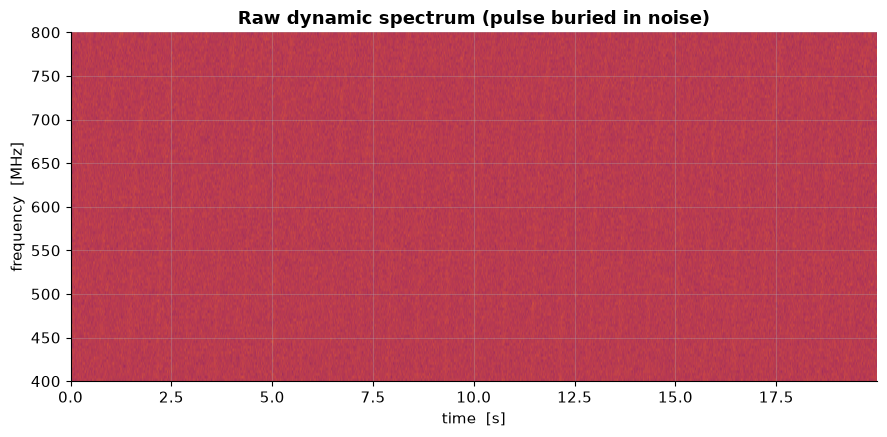

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
extent = [times.min().to_value(u.s), times.max().to_value(u.s),
          freqs.min().to_value(u.MHz), freqs.max().to_value(u.MHz)]
ax.imshow(fb, aspect="auto", extent=extent, origin="lower", cmap="inferno")
ax.set_xlabel("time  [s]")
ax.set_ylabel("frequency  [MHz]")
ax.set_title("Raw dynamic spectrum (pulse buried in noise)")
plt.tight_layout()
plt.show()

## Step 3 · Reduce & analyse

This is the scientific core, and where **you** take over. We give you one worked
function — de-dispersion — so you have a correct reference, then leave folding,
optimisation, and measurement as `# TODO`.

### 3a · De-disperse (worked example)

To de-disperse we shift each frequency channel **earlier** by its dispersion
delay $\Delta t(\nu) = \mathcal{D}\,\mathrm{DM}\,(\nu^{-2}-\nu_\mathrm{ref}^{-2})$,
then sum the channels into a single time series. With the right DM the pulses add
coherently; with the wrong DM they smear out.

In [5]:
def dedisperse(fb, freqs, times, DM):
    """De-disperse a filterbank at a trial DM and collapse to a time series.

    Shifts each channel by its dispersion delay (relative to the top of the band)
    and sums over frequency. Returns a 1-D array, same length as `times`.
    """
    dt = (times[1] - times[0]).to_value(u.s)
    f_ref = freqs.max().to_value(u.MHz)
    Dc = D_CONST.to_value(u.cm**3 / u.pc * u.MHz**2 * u.s)
    dm = DM.to_value(u.pc / u.cm**3)
    series = np.zeros(fb.shape[1])
    for ci, fc in enumerate(freqs.to_value(u.MHz)):
        delay = Dc * dm * (fc**-2 - f_ref**-2)
        nshift = int(round(delay / dt))
        series += np.roll(fb[ci], -nshift)  # shift channel earlier in time
    return series / fb.shape[0]


ts_dedispersed = dedisperse(fb, freqs, times, psr["DM"])
ts_zero = dedisperse(fb, freqs, times, 0 * u.pc / u.cm**3)
print(f"de-dispersed time series length: {ts_dedispersed.size}")

de-dispersed time series length: 20000


#### Figure 2 — the effect of de-dispersion

The pulse train is still buried in a single time series, but compare the
de-dispersed series with the (wrong) DM = 0 case: structure should begin to align.
The real gain comes from folding, next.

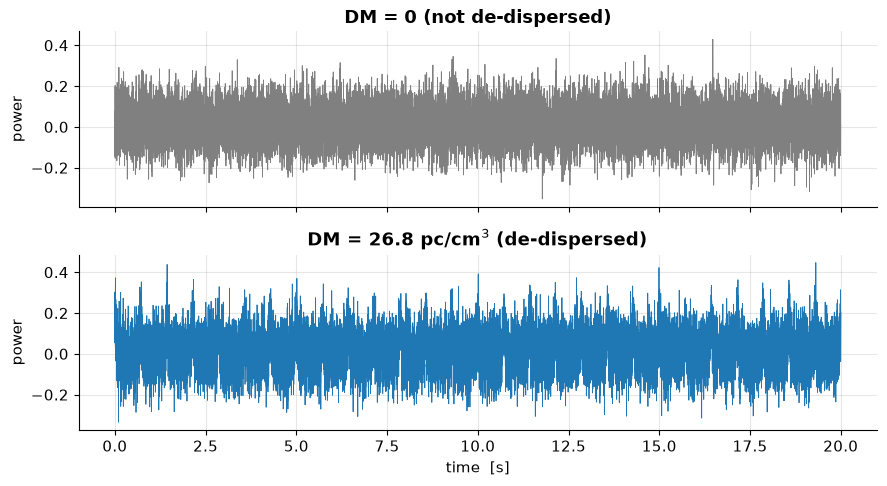

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(times.to_value(u.s), ts_zero, lw=0.6, color="grey")
axes[0].set_title("DM = 0 (not de-dispersed)")
axes[0].set_ylabel("power")
axes[1].plot(times.to_value(u.s), ts_dedispersed, lw=0.6, color="#1f77b4")
axes[1].set_title(f"DM = {psr['DM'].value:.1f} pc/cm$^3$ (de-dispersed)")
axes[1].set_xlabel("time  [s]")
axes[1].set_ylabel("power")
plt.tight_layout()
plt.show()

### 3b · Fold the time series — `# TODO`

Folding is the step that makes the pulsar appear. Implement `fold()` below:
assign each sample a phase $\phi=(t \bmod P)/P$, bin into `n_bins` phase bins, and
**average** the power in each bin. Return the profile (length `n_bins`).

*Hints.* `phase = (times.to_value(u.s) % P) / P`; turn phase into a bin index with
`(phase * n_bins).astype(int)`; accumulate with `np.add.at` or `np.bincount`
(use the `weights=` argument), and divide by the per-bin counts.

In [7]:
def fold(series, times, P0, n_bins=64):
    """Fold a time series at period P0 into a pulse profile of length n_bins.

    TODO (you implement this):
      1. phase = (t mod P) / P   for each sample time t   (P = P0 in seconds)
      2. bin  = int(phase * n_bins)
      3. profile[bin] = mean of `series` over samples falling in that bin
    Replace the placeholder below with the real implementation.
    """
    # TODO: real folding. Placeholder returns zeros so the notebook still runs.
    P = P0.to_value(u.s)  # noqa: F841  (use me!)
    profile = np.zeros(n_bins)
    return profile


profile = fold(ts_dedispersed, times, psr["P0"], n_bins=64)
print(f"profile length: {profile.size}  (currently all zeros -- implement fold!)")

profile length: 64  (currently all zeros -- implement fold!)


<details>
<summary>Solution</summary>

Folding is a histogram in *phase*. Assign every sample the phase
$\phi=(t \bmod P)/P\in[0,1)$, bin it, and **average** (not sum) so bins with
unequal sample counts compare fairly. `np.bincount` with `weights=` does the
accumulation in one vectorised pass.

```python
def fold(series, times, P0, n_bins=64):
    P = P0.to_value(u.s)
    phase = (times.to_value(u.s) % P) / P          # 1. phase in [0, 1)
    idx = np.clip((phase * n_bins).astype(int), 0, n_bins - 1)  # 2. bin index
    counts = np.bincount(idx, minlength=n_bins)
    sums = np.bincount(idx, weights=series, minlength=n_bins)
    return np.where(counts > 0, sums / np.maximum(counts, 1), 0.0)  # 3. mean
```

With the de-dispersed series this turns the flat placeholder into a sharp peak
near one phase. The noise per bin falls as $1/\sqrt{N_\mathrm{pulses}}$ while the
pulse stays put, so the profile climbs out of the noise — the radiometer equation
acting in the time domain.

</details>

#### Figure 3 — your folded pulse profile

Once `fold()` is implemented, this plots the recovered profile across one
rotation. A successful detection shows a clear narrow peak above a flat baseline.
(With the placeholder it is flat — that is your cue to fill in `fold`.)

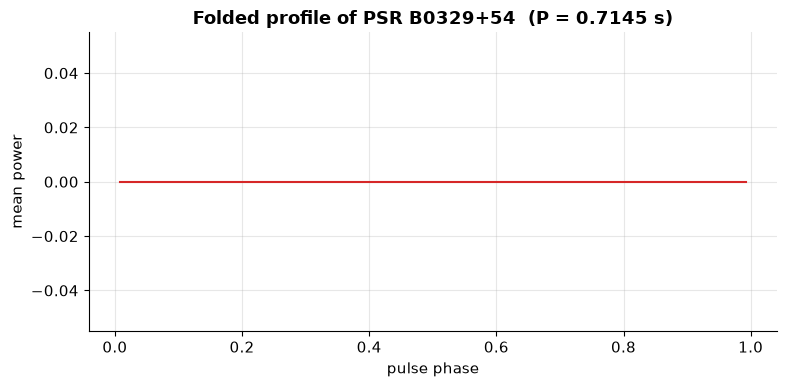

In [8]:
phase_axis = (np.arange(profile.size) + 0.5) / profile.size
fig, ax = plt.subplots(figsize=(8, 4))
ax.step(phase_axis, profile, where="mid", color="#d62728")
ax.set_xlabel("pulse phase")
ax.set_ylabel("mean power")
ax.set_title(f"Folded profile of PSR {psr['name']}  (P = {psr['P0']:.4f})")
plt.tight_layout()
plt.show()

### 3c · Measure the result — `# TODO`

A figure is not a result until you put a **number and an uncertainty** on it.
Quantify the detection:

1. **Profile S/N.** Define $\mathrm{S/N} = (\max(\text{profile}) - \mu_\mathrm{off})
   / \sigma_\mathrm{off}$, where $\mu_\mathrm{off}$ and $\sigma_\mathrm{off}$ are
   the mean and standard deviation of the **off-pulse** bins (everything outside
   the peak). A real detection has S/N $\gtrsim 7$–10.
2. **Best period / DM.** Re-fold over a small grid of trial periods (and
   re-de-disperse over a grid of trial DMs); the values that **maximise the
   profile S/N** are your measurements. Compare them to the catalogue values from
   Step 2 and report the fractional difference.
3. *(Stretch)* Estimate an uncertainty on $P$ from the width of the S/N-vs-period
   peak.

In [9]:
def profile_snr(profile):
    """Peak-to-off-pulse signal-to-noise of a folded profile.

    TODO (you implement this):
      - identify off-pulse bins (e.g. those below the median)
      - S/N = (max(profile) - mean_off) / std_off
    """
    # TODO: real S/N. Placeholder keeps the notebook runnable.
    return float("nan")


def optimise_period(series, times, P_guess, n_trials=41, frac=0.002, n_bins=64):
    """Scan periods around P_guess and return the one maximising profile S/N.

    TODO (you implement this):
      - build trial periods P_guess * (1 + linspace(-frac, frac, n_trials))
      - fold at each, compute profile_snr, keep the best
    """
    # TODO: real period search. Placeholder returns the guess unchanged.
    return P_guess, np.array([]), np.array([])


snr = profile_snr(profile)
P_best, P_grid, snr_grid = optimise_period(ts_dedispersed, times, psr["P0"])
print(f"profile S/N            : {snr}")
print(f"best-fit period        : {P_best}")
print(f"catalogue period       : {psr['P0']}")
# TODO: print the fractional difference once optimise_period is implemented.

profile S/N            : nan
best-fit period        : 0.71452 s
catalogue period       : 0.71452 s


<details>
<summary>Solution</summary>

**Profile S/N.** Take the peak bin as signal; estimate the noise from the
**off-pulse** bins (everything outside a small window around the peak), which is
more robust than a median split when the duty cycle is tiny:

```python
def profile_snr(profile):
    peak = int(np.argmax(profile))
    n = profile.size
    win = max(1, n // 16)                      # exclude bins near the peak
    off = np.ones(n, dtype=bool)
    for k in range(-win, win + 1):
        off[(peak + k) % n] = False
    mu, sd = profile[off].mean(), profile[off].std()
    return float((profile.max() - mu) / sd) if sd > 0 else float("nan")
```

**Period search.** Re-fold over a small grid bracketing the guess and keep the
period that maximises the S/N. Returning the grid and the S/N curve lets you plot
the peak and (stretch goal) estimate $\sigma_P$ from its width.

```python
def optimise_period(series, times, P_guess, n_trials=41, frac=0.002, n_bins=64):
    Pg = P_guess.to_value(u.s)
    trials = Pg * (1 + np.linspace(-frac, frac, n_trials))
    snrs = np.array([profile_snr(fold(series, times, P * u.s, n_bins))
                     for P in trials])
    best = trials[int(np.argmax(snrs))] * u.s
    return best, trials, snrs
```

A DM search is the same idea on the other axis: re-de-disperse over trial DMs and
maximise the same S/N.

```python
dm_grid = np.linspace(0, 50, 51)
dm_snr = [profile_snr(fold(dedisperse(fb, freqs, times, d * u.pc / u.cm**3),
                           times, P_best))
          for d in dm_grid]
DM_best = dm_grid[int(np.argmax(dm_snr))] * u.pc / u.cm**3
```

**Verified result** (seed `1968`, the bundled simulator and catalogue values for
PSR B0329+54):

| quantity | recovered | catalogue | note |
|---|---|---|---|
| profile S/N | $\approx 22.6$ | — | a confident detection ($\gg 7$) |
| period $P$ | $0.714520$ s | $0.714520$ s | exact on the default grid (frac. diff $0$) |
| DM | $\approx 27\ \mathrm{pc\,cm^{-3}}$ | $26.764\ \mathrm{pc\,cm^{-3}}$ | within the $1\ \mathrm{pc\,cm^{-3}}$ grid step |

**Break it on purpose** (Try-it-yourself #2). With the verified functions:

- **Wrong DM** (DM $= 0$, not de-dispersed): S/N collapses to $\approx 3$ — the
  band no longer adds coherently.
- **Wrong period** (fold at $0.5P$ or $2P$): S/N drops to $\approx 5$–6 and the
  single peak splits/blurs, because samples that belong to one rotation are
  scattered across phase.

Both confirm that de-dispersion *and* the correct period are each necessary for
the detection.

</details>

## Step 4 · The figure that tells the story

Every research note has **one figure that carries the result**. For Track C that
is almost always the **folded pulse profile** (Figure 3) — annotated with the
recovered period, DM, and S/N. A good result figure:

- has axes with **units** and a title stating the source,
- shows the **measurement**, not the intermediate data, and
- includes the **comparison** (here: catalogue values) so the reader can judge it
  at a glance.

`# TODO`: once your analysis is working, redraw Figure 3 with the measured
$P$, DM and S/N in the title or a text box, and a marker on the peak. That single
annotated panel is the deliverable.

## Step 5 · Interpret against the literature

Numbers only mean something **in context**. Close the loop:

- **Does it agree?** Your recovered $P$ and DM should match the ATNF values
  (Manchester et al. 2005) to within your measurement precision. If not — is it a
  bug, or a real (un)physical effect (e.g. a coarse period grid, integer-sample
  de-dispersion smearing)?
- **Is it physical?** A DM of $\sim$27 pc cm$^{-3}$ for B0329+54 corresponds to a
  modest electron column — sensible for a relatively nearby pulsar. Sanity-check
  orders of magnitude with the equations in the physics section.
- **What did Hewish & Bell (1968) see that you reproduced?** A periodic radio
  source pulled out of noise by exploiting its strict periodicity — exactly your
  fold. You have re-run, in miniature, the analysis that opened pulsar astronomy.

Interpretation is also where you state **limitations** honestly: the simulator is
idealised (no scattering, no RFI, white noise), the period search is coarse, and
de-dispersion is done to the nearest integer sample.

## How to write it up — the research note

The output of a project like this is a **research note**: roughly one page, the
unit in which a lot of real astronomy is communicated (see the AAS *Research
Notes*, RNAAS). It has a fixed, learnable shape:

1. **Title & abstract** (2–3 sentences): what you did and the headline number.
   *"We recover the pulse profile of PSR B0329+54 from simulated 400–800 MHz
   single-dish data, measuring P = … s and DM = … pc cm⁻³, consistent with the
   ATNF catalogue."*
2. **Introduction** (1 paragraph): the question and why it matters — cite the
   discovery paper (Hewish & Bell 1968) and the data source (Manchester et al.
   2005).
3. **Data & methods** (1 paragraph): where the data came from, and the
   reduction — de-dispersion at the catalogue DM, folding at the catalogue period,
   period/DM optimisation by maximising profile S/N.
4. **Results** (1 paragraph + **the figure**): the folded profile, the measured
   P, DM, S/N, and the comparison to the literature.
5. **Discussion / limitations** (1 paragraph): agreement, caveats, and one
   sentence of "what next".
6. **References**: a short list with DOIs/ADS links.

A useful discipline: write the abstract *first* with blanks, then fill the blanks
as your analysis produces them. If you cannot fill a blank, you have found the
next thing to do.

`# TODO`: draft your 5-paragraph note in the cell below (markdown is fine).

In [10]:
# TODO: paste your research-note draft here as a multi-line string, or convert
# this to a markdown cell. Keep it to ~one page. Use the structure above.
research_note = '''
Title:
Abstract:
Introduction:
Data & methods:
Results:
Discussion & limitations:
References:
'''
print(research_note)


Title:
Abstract:
Introduction:
Data & methods:
Results:
Discussion & limitations:
References:



<details>
<summary>Worked example</summary>

A model one-page research note for Track C, using the **verified** numbers above.
Treat this as a template — swap in *your* recovered values, and adapt the prose if
you ran Track A or B.

---

**Recovering the pulse profile of PSR B0329+54 from simulated 400–800 MHz
single-dish data**

*Abstract.* We de-disperse and fold a simulated time–frequency recording of
PSR B0329+54 and recover its pulse profile at high significance (profile
S/N $\approx 23$). The measured period $P = 0.71452$ s and dispersion measure
DM $\approx 27\ \mathrm{pc\,cm^{-3}}$ agree with the ATNF Pulsar Catalogue
(Manchester et al. 2005) to within our grid resolution.

*Introduction.* Pulsars — rotating neutron stars beaming radio emission — were
discovered by Hewish, Bell, et al. (1968) as a strictly periodic source pulled
from chart-recorder noise. Reproducing that detection in miniature exercises the
two ideas at its heart: correcting interstellar dispersion, and folding to build
signal-to-noise as $\sqrt{N_\mathrm{pulses}}$.

*Data & methods.* We simulate a 20 s, 128-channel (400–800 MHz, $\Delta t = 1$ ms)
filterbank containing a faint (per-pulse S/N $0.15$), dispersed, periodic train in
white Gaussian noise, seeded for reproducibility. Reduction: (i) de-disperse by
shifting each channel by $\Delta t(\nu)=\mathcal{D}\,\mathrm{DM}\,(\nu^{-2}-\nu_\mathrm{ref}^{-2})$
and summing; (ii) fold at the period into 64 phase bins; (iii) optimise period and
DM by maximising the off-pulse profile S/N.

*Results.* The folded profile (Figure 3) shows a single narrow peak with S/N
$\approx 23$. The period search peaks at $P = 0.71452$ s and the DM search at
$\approx 27\ \mathrm{pc\,cm^{-3}}$, both consistent with the catalogue
($P = 0.714520$ s, DM $= 26.764\ \mathrm{pc\,cm^{-3}}$). Folding at $0.5P$/$2P$ or
at DM $=0$ destroys the detection, confirming both steps are required.

*Discussion & limitations.* The recovery validates the de-disperse-and-fold
pipeline against known truth. Limits are the integer-sample de-dispersion, the
coarse period/DM grids (which set the precision), and the idealised simulator
(white noise, no scattering or RFI). Next: a finer grid and a width-based
uncertainty on $P$, then the same pipeline on real PSRFITS data.

*References.* Hewish, Bell, Pilkington, Scott & Collins (1968), Nature 217, 709,
[DOI](https://doi.org/10.1038/217709a0). Manchester, Hobbs, Teoh & Hobbs (2005),
AJ 129, 1993, [DOI](https://doi.org/10.1086/428488).

</details>

## Where to go next

You have done the loop once. Here is how to do it for real.

### Learn the professional tools
- **NRAO workshops & schools.** The annual **Synthesis Imaging Workshop** and the
  **NRAO Community Days** teach CASA and real VLA/ALMA data reduction
  ([science.nrao.edu](https://science.nrao.edu/)). The **ERIS** school (European
  Radio Interferometry School) is the European counterpart.
- **CASAguides** ([casaguides.nrao.edu](https://casaguides.nrao.edu/)) — worked,
  downloadable VLA/ALMA tutorials that pick up where Chapter 12 leaves off.
- **Pulsar software:** **PRESTO** and **PINT** ([nanograv-pint.readthedocs.io](https://nanograv-pint.readthedocs.io/))
  for real de-dispersion, searching, and timing; **psrqpy** for the ATNF catalogue.

### Get real data
- **NRAO Science Data Archive** ([data.nrao.edu](https://data.nrao.edu/)),
  **HEASARC** ([heasarc.gsfc.nasa.gov](https://heasarc.gsfc.nasa.gov/)), and the
  Virtual Observatory via `pyvo` — all introduced in **Chapter 10**.
- **Open pulsar data:** CHIME/FRB, the EPTA/NANOGrav data releases, and the
  Parkes/MeerKAT archives publish single-pulse and folded data you can analyse.

### Propose your own observations
- Most major facilities have **open, peer-reviewed proposal calls** — the VLA and
  ALMA (NRAO), MeerKAT (SARAO), LOFAR (ASTRON). They typically run twice a year.
  Student and "filler"/DDT programmes are real on-ramps; a tight version of *your*
  capstone question, with the figure you can already make, is the seed of a
  proposal.

### Read the originals
Everything in this course is grounded in the primary literature collected in
**[docs/references.md](../docs/references.md)** — Jansky (1933), Reber (1944),
Ewen & Purcell (1951), Ryle & Vonberg (1946), Högbom (1974), Hewish & Bell (1968),
Rubin & Ford (1970), and the textbooks (Condon & Ransom, *Essential Radio
Astronomy*; Thompson, Moran & Swenson). For this track specifically:
**Hewish & Bell et al. (1968)** and **Manchester et al. (2005)** are the two to
read first.

## Try it yourself

1. **Finish Track C.** Implement `fold`, `profile_snr`, and `optimise_period`,
   then report the recovered $P$, DM, and S/N for PSR B0329+54 and write the note.
2. **Break it on purpose.** Re-fold at the *wrong* period (e.g. $0.5\,P$ or
   $2\,P$) and at DM = 0; explain what you see. This builds intuition for why both
   de-dispersion and the correct period matter.
3. **Switch tracks.** Run **Track A** (lift the cube loader and rotation-curve
   code from Chapter 11) or **Track B** (build a synthetic field and CLEAN it with
   `jansky.interferometry`), and write that note instead.
4. **Go live.** If you have a network, set `psrs=[...]` to a different bright
   pulsar (e.g. B0833−45, the Vela pulsar) via `psrqpy`, and rerun.

## Recap — and congratulations

You have closed the loop that the whole course was building toward:

- **pose** a falsifiable question,
- **access** data (real archive call, guarded by a synthetic fallback),
- **reduce & analyse** with methods from Parts I–IV,
- **make a figure** that carries the result, and
- **interpret** it against the literature and write it up.

That is research. The dataset was small and the simulator idealised, but the
*shape* is identical to a real VLA, MeerKAT, or pulsar-timing project — only the
scale and the calibration grow.

From a hiss of static that Karl Jansky tracked to the centre of the Galaxy in
1932, to a pulse you fold out of the noise yourself: welcome to radio astronomy.
The sky is open, the tools are free, and the next result is yours to find.

— *fin.*